## 🔍 EDA en el contexto de CRISP-DM

### 1. **Objetivo del EDA**
- Comprender la naturaleza de los datos antes de aplicar modelos.
- Detectar patrones, anomalías y relaciones.
- Evaluar la calidad y completitud de los datos.
- Generar hipótesis iniciales sobre el problema de negocio.

---

### 2. **Pasos clave del EDA**
#### a) **Anatomía y estructura básica (Revisión inicial de los datos)**

- ¿Qué verificar? Dimensiones del dataset ($N$ filas $\times$ $M$ columnas), tipos de datos por columna (int, float, object, datetime), uso de memoria.
- Pregunta de reflexión: ¿Las variables continuas están tipeadas como texto por algún símbolo extraño (ej. "$1,200")?

#### b) **Calidad de los datos**
- Valores faltantes (Nulls/NaNs): ¿Faltan al azar o hay un patrón sistémico? (Ej. Un sensor que se apaga a medianoche).
- Duplicados: Filas completamente idénticas o IDs repetidos..
- Errores de formato (ej. fechas mal registradas).
- Outliers (Valores atípicos): ¿Son errores de digitación (un cliente de 150 años) o eventos raros reales que interesan al negocio?.

#### c) **Análisis Univariado (Distribución de variables)**
- Histogramas y frecuencias.
- Medidas de tendencia central (media, mediana, moda).
- Medidas de dispersión (varianza, desviación estándar).
- Ejemplo: distribución de ingresos de clientes para detectar sesgos.
- Variables Numéricas: Distribución (histogramas, Boxplots), sesgo (skewness), escalas.
- Variables Categóricas: Frecuencias de clases (gráficos de barras), cardinalidad (¿hay categorías con 1000 valores únicos distintos?).

#### d) **Análisis Bivariado (Relaciones entre variables)**
- Correlaciones (Pearson, Spearman).
- Tablas cruzadas para variables categóricas.
- Ejemplo: relación entre nivel educativo y salario.
- Cruces Clave: ¿Cómo se comporta la variable objetivo (ej. Churn) frente a variables continuas (ej. Monto Consumido) y categóricas (ej. Tipo de Plan)?

#### e) **Generación de hipótesis y hallazgos**
- Resumir qué variables parecen ser las más predictivas y qué problemas requerirán ingeniería de características (Fase 3).


### 5. **Actividad práctica en clase**
- Cada grupo usa el dataset planteado para su proyecto de la materia 
- Presentación rápida de hallazgos (10 min por grupo).

# 1. LIBRERIAS Y FUNCIONES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. PARÁMETROS

# 3. DATOS

In [2]:
# df: data_frame
df_bfv = pd.read_csv("data/black_friday_ventas.csv")
df_bfv.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


# 4. PROCESO

## 4.1 Pasos de EDA

Filas: 550068 | Columnas: 12
<class 'pandas.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  str    
 2   Gender                      550068 non-null  str    
 3   Age                         550068 non-null  str    
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  str    
 6   Stay_In_Current_City_Years  550068 non-null  str    
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), str(5)
memory usage: 50.4 MB


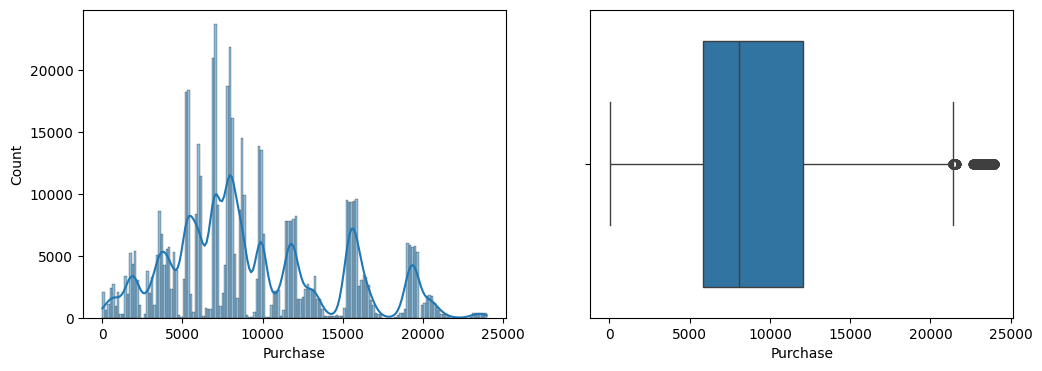

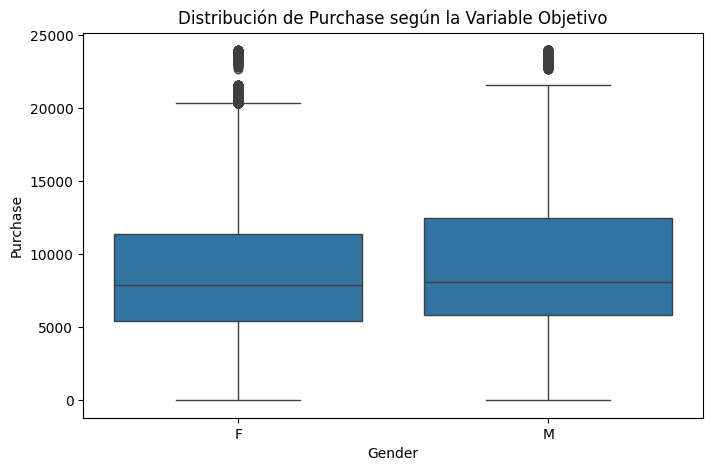

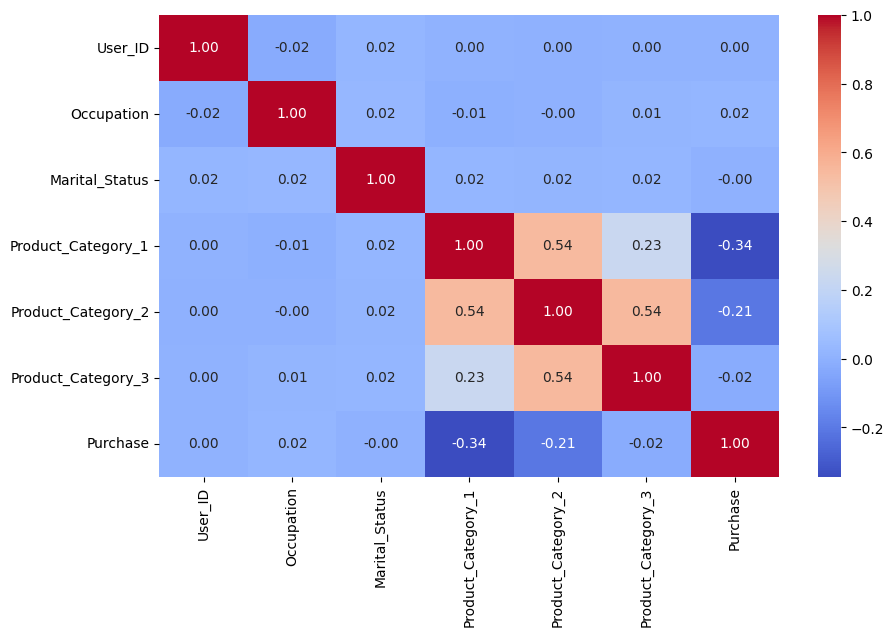

In [3]:
# 1. ANATOMÍA Y ESTRUCTURA
#df_bfv = pd.read_csv("tu_dataset.csv")
print(f"Filas: {df_bfv.shape[0]} | Columnas: {df_bfv.shape[1]}")
print(df_bfv.info())

# 2. CALIDAD DE DATOS (Faltantes y Duplicados)
missing_summary = pd.DataFrame({
    'NaNs': df_bfv.isnull().sum(),
    '% NaNs': (df_bfv.isnull().sum() / len(df_bfv)) * 100
}).sort_values('% NaNs', ascending=False)
print(missing_summary[missing_summary['NaNs'] > 0])

# 3. ANÁLISIS UNIVARIADO (Ejemplo Numérico)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_bfv['Purchase'], kde=True, ax=axes[0])
sns.boxplot(x=df_bfv['Purchase'], ax=axes[1])
plt.show()

# 4.1 ANÁLISIS BIVARIADO (Relación Feature vs Target)
plt.figure(figsize=(8, 5))
sns.boxplot(x='Gender', y='Purchase', data=df_bfv)
plt.title('Distribución de Purchase según la Variable Objetivo')
plt.show()

# 4.2 MATRIZ DE CORRELACIÓN
plt.figure(figsize=(10, 6))
sns.heatmap(df_bfv.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

## 4.2. Algunos ajustes en base a los pasos EDA

In [6]:
df_bfv.head(2)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200


- Dimensiones del dataset

In [5]:
# número de filas y columnas
df_bfv.shape

(550068, 12)

Nuestro conjunto de datos esta comprendido por: 
- 550K registros 
- 12 variables    

In [25]:
# tipos de variables, revisar el tipo de variable
df_bfv.dtypes

User_ID                           str
Product_ID                        str
Gender                            str
Age                               str
Occupation                        str
City_Category                     str
Stay_In_Current_City_Years        str
Marital_Status                  int64
Product_Category_1              int64
Product_Category_2            float64
Product_Category_3            float64
Purchase                        int64
dtype: object

Descripción de variables:
- User_ID: Identificador unico de usuario o cliente, tipo de dato: categorico
- Age: Edad ; tipo de dato: es de tipo categorico porque muestra intervalos de edad por registro

In [24]:
df_bfv['User_ID'] = df_bfv['User_ID'].astype(str)
df_bfv['Occupation'] = df_bfv['Occupation'].astype(str)

In [26]:
# valores faltantes
df_bfv.isnull().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            173638
Product_Category_3            383247
Purchase                           0
dtype: int64

In [6]:
173/550

0.3145454545454546

Redacción sobre análisis de valores faltantes en las variables de estudio:
- Para la variable Product_Category_2 se tiene un total de 173K(31%) valores faltante de 550K registros 

In [31]:
# imputaremos la vairbale product?catregory_2 porla moda
moda = df_bfv['Product_Category_2'].mode()[0]
df_bfv['Product_Category_2'] = df_bfv['Product_Category_2'].fillna(moda)

Completamos los valores faltante de la variable Product_Category_2, con su valor mas frecuente (moda), con el fin de tener datos completos. 

In [33]:
df_bfv.isnull().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2                 0
Product_Category_3            383247
Purchase                           0
dtype: int64

In [36]:
# revisaremos las filas duplicas y las eliminamos
print('filas originales del data frame',df_bfv.shape)
print('filas después de eliminar duplicados',df_bfv.drop_duplicates().shape)

filas originales del data frame (550068, 12)
filas después de eliminar duplicados (550068, 12)


## 4.2. (5) Generación de hipótesis y hallazgos

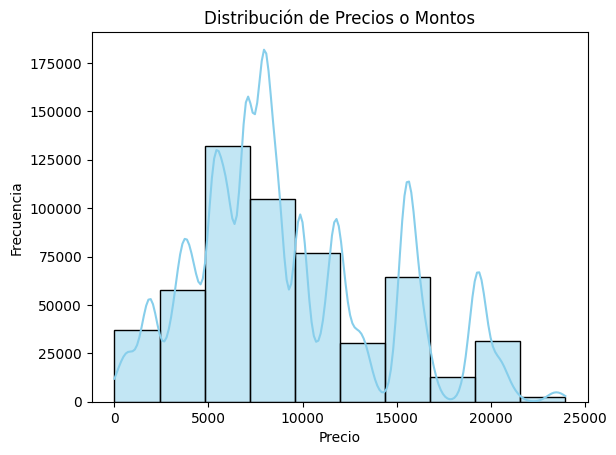

In [37]:
# HISTOGRAMA

# Histograma con Seaborn
sns.histplot(df_bfv["Purchase"], bins=10, kde=True, color="skyblue")
plt.title("Distribución de Precios o Montos")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.show()

Para la variable precio, en base al histograma se puede ver que su distirbución no es simetrica, tiene un sesgo hacia la derecha. 
El valor mas frecuente(moda) o con mas densidad se encuentra aproximadamente en $6000.-


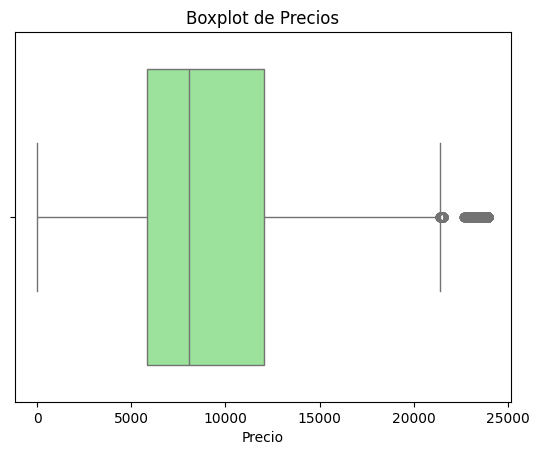

In [38]:
# Boxplot(diagrama de cajas bigotes) con Seaborn
sns.boxplot(x=df_bfv["Purchase"], color="lightgreen")
plt.title("Boxplot de Precios")
plt.xlabel("Precio")
plt.show()

**La variable precio presenta Outliers, que alcanzan valores aprox. a 24000$** 

Resultados: 
- El valor minimo es 0$
- El valor máximo es aprox. 22000$
- La mediana de la variable precio es aprox $8000, es decir el 50% de los registros esta por encima de la median y el otro 50% esta por debajo de este valor. 
- Percentil 25 se encuentra aprox en 6000$
- Percentil 75 se encuentra aprox 12000$
- La variable precio presenta Outlier, que alcanzan valores aprox. a 24000$ 

# 5. SALIDA